# E-Commerce Customer Churn Analysis

## Project Overview

This notebook analyzes customer behavior in an e-commerce dataset to understand the factors associated with customer churn.

### Main business question

> **What customer behaviors and characteristics are associated with churn?**

### Supporting questions

1. What proportion of customers churn?
2. Which customer behaviors are most strongly associated with churn?
3. Does customer engagement relate to churn?
4. How are purchase behavior, cart abandonment, returns, and service calls related to churn?
5. Are there meaningful differences across gender, country, and signup quarter?
6. Can machine learning help identify customers at higher risk of churn?

### Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook

### Dataset

**File:** `ecommerce_customer_churn_dataset.csv`

**Note:** The analysis is based on the provided dataset. Any business interpretation should be treated as an association, not proof of causation.

## 1. Import Libraries

The notebook avoids installing packages during analysis. Install dependencies once using the project's `requirements.txt` file before running the notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score
)
#create visuals folder automatically
os.makedirs("visualisation", exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Load the Dataset

The path resolver supports a common project structure where the notebook is stored in the project root and the CSV is inside a `Data` folder.

In [2]:
candidate_paths = [
    Path("Data/ecommerce_customer_churn_dataset.csv"),
    Path("../Data/ecommerce_customer_churn_dataset.csv"),
    Path("ecommerce_customer_churn_dataset.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place 'ecommerce_customer_churn_dataset.csv' "
        "inside the Data folder or next to this notebook."
    )

df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded from: ..\Data\ecommerce_customer_churn_dataset.csv
Rows: 50,000
Columns: 25


In [3]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.000,Male,France,Marseille,2.900,14.000,27.400,6.000,50.600,3.000,9.000,94.720,34.000,46.400,2.000,17.900,9.000,4.000,16.300,20.800,1.000,953.330,"2,278.000",0,Q1
1,36.000,Male,UK,Manchester,1.600,15.000,42.700,10.300,37.700,1.000,19.500,82.450,71.000,57.960,9.200,42.800,7.000,3.000,NaN,23.300,3.000,"1,067.470","3,028.000",0,Q4
2,45.000,Female,Canada,Vancouver,2.900,10.000,24.800,1.600,70.900,1.000,9.100,165.520,11.000,12.240,11.500,0.000,4.000,1.000,NaN,8.800,NaN,"1,289.750","2,317.000",0,Q4
3,56.000,Female,USA,New York,2.600,10.000,38.400,14.800,41.700,9.000,15.000,147.330,47.000,44.100,5.400,41.400,2.000,5.000,85.900,31.000,3.000,"2,340.920","2,674.000",0,Q1
4,35.000,Male,India,Delhi,3.100,29.000,51.400,NaN,19.100,9.000,32.500,141.300,73.000,25.200,5.500,37.900,1.000,11.000,83.000,50.400,4.000,"3,041.290","5,354.000",0,Q4


## 3. Dataset Structure

Before cleaning or modeling, inspect the dataset structure, data types, and summary statistics.

In [4]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

Shape: (50000, 25)

Column names:
['Age', 'Gender', 'Country', 'City', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned', 'Signup_Quarter']

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 no

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,"47,505.000",NaN,NaN,NaN,37.803,11.835,5.000,29.000,38.000,46.000,200.000
Gender,50000,3,Female,25116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,50000,8,USA,17384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,50000,40,Houston,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership_Years,"50,000.000",NaN,NaN,NaN,2.984,2.059,0.100,1.400,2.500,4.000,10.000
Login_Frequency,"50,000.000",NaN,NaN,NaN,11.625,7.811,0.000,6.000,11.000,17.000,46.000
Session_Duration_Avg,"46,601.000",NaN,NaN,NaN,27.661,10.871,1.000,19.700,26.800,34.700,75.600
Pages_Per_Session,"47,000.000",NaN,NaN,NaN,8.738,3.778,1.000,6.000,8.400,11.200,24.100
Cart_Abandonment_Rate,"50,000.000",NaN,NaN,NaN,57.080,16.283,0.000,46.400,58.100,68.700,143.743
Wishlist_Items,"46,000.000",NaN,NaN,NaN,4.298,3.190,0.000,2.000,4.000,6.000,28.000


## 4. Data Quality Checks

We will check duplicates, missing values, and unusual numeric values before making any cleaning decisions.

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [7]:
missing_summary = (
    pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_Percentage": df.isna().mean().mul(100)
    })
    .query("Missing_Count > 0")
    .sort_values("Missing_Percentage", ascending=False)
)

missing_summary

,Missing_Count,Missing_Percentage
Social_Media_Engagement_Score,6000,12.000
Credit_Balance,5500,11.000
Mobile_App_Usage,5000,10.000
Returns_Rate,4491,8.982
Wishlist_Items,4000,8.000
Discount_Usage_Rate,3500,7.000
Product_Reviews_Written,3500,7.000
Session_Duration_Avg,3399,6.798
Pages_Per_Session,3000,6.000
Days_Since_Last_Purchase,3000,6.000


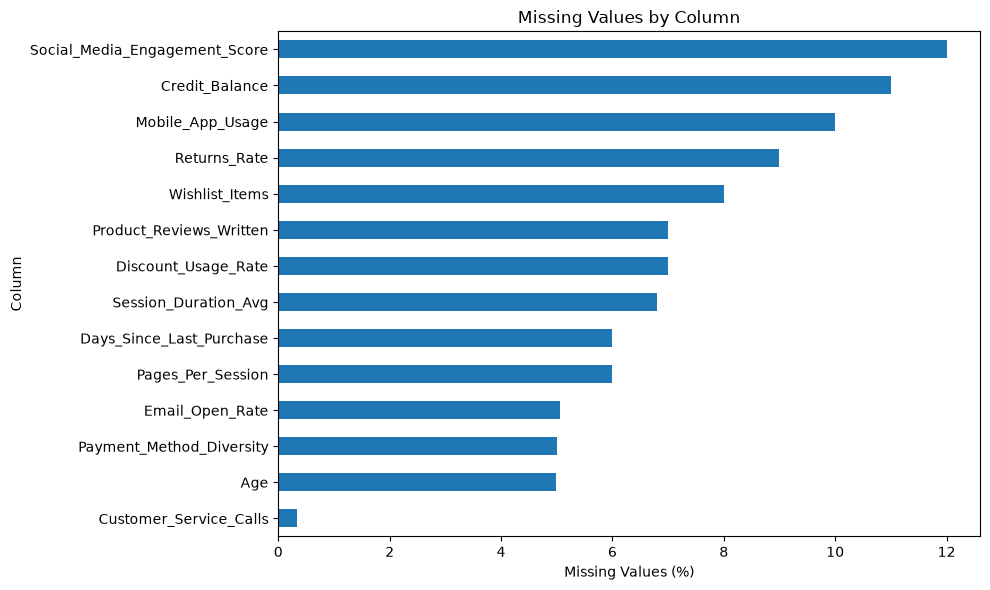

In [8]:
plt.figure(figsize=(10, 6))
missing_summary["Missing_Percentage"].sort_values().plot(kind="barh")
plt.title("Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.savefig(
    "visualisation/Missing_Values_by_Column.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

### Missing-value interpretation

The dataset contains missing values in several behavioral variables. No single variable exceeds 12% missingness, so columns should not be removed solely because they contain missing values.

For modeling, numeric missing values will be imputed using the **median learned from the training data only**. This prevents data leakage.

Categorical missing values will be filled with the most frequent category.

## 5. Data Quality: Age Check

Age contains a small amount of missing data and includes unusually high values. We will inspect these records before deciding whether they should be treated as invalid.

In [9]:
print("Age statistics:")
print(df["Age"].describe())

print("\nAge values above 80:")
display(df.loc[df["Age"] > 80, ["Age", "Gender", "Country"]].sort_values("Age").head(20))

print(f"\nMissing Age values: {df['Age'].isna().sum():,}")

Age statistics:
count   47,505.000
mean        37.803
std         11.835
min          5.000
25%         29.000
50%         38.000
75%         46.000
max        200.000
Name: Age, dtype: float64

Age values above 80:


,Age,Gender,Country
6715,150.000,Male,Australia
46351,150.000,Male,Australia
12960,150.000,Female,USA
16924,150.000,Male,India
17932,150.000,Female,Japan
45628,150.000,Male,USA
42707,150.000,Female,USA
39434,150.000,Female,UK
35800,150.000,Female,USA
40909,200.000,Female,USA



Missing Age values: 2,495


### Cleaning assumption

For this project, customer age is expected to represent an adult e-commerce customer. Ages below 18 or above 80 are therefore flagged as potentially invalid for analysis.

This is an **explicit project assumption**, not a claim about the original data-generating process. The raw dataset remains unchanged; a cleaned analytical copy is created below.

In [10]:
analysis_df = df.copy()

invalid_age = analysis_df["Age"].notna() & (
    (analysis_df["Age"] < 18) | (analysis_df["Age"] > 80)
)

print(f"Potentially invalid age records: {invalid_age.sum():,}")

analysis_df.loc[invalid_age, "Age"] = np.nan

Potentially invalid age records: 50


## 6. Churn Overview

`Churned = 1` represents a churned customer and `Churned = 0` represents a retained customer.

In [11]:
churn_counts = analysis_df["Churned"].value_counts().sort_index()
churn_rate = analysis_df["Churned"].mean()

print("Customer counts:")
print(churn_counts)

print(f"\nOverall churn rate: {churn_rate:.1%}")

Customer counts:
Churned
0    35550
1    14450
Name: count, dtype: int64

Overall churn rate: 28.9%


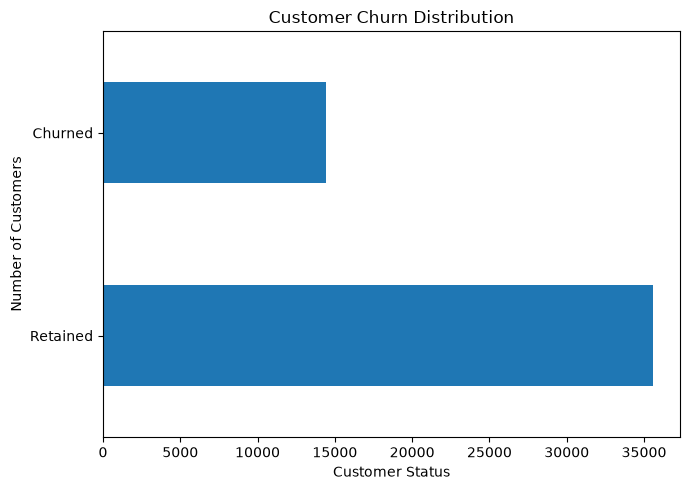

In [12]:
plt.figure(figsize=(7, 5))
churn_counts.rename({0: "Retained", 1: "Churned"}).plot(kind="barh")
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "visualisation/customer_churn_distribution.png"
)
plt.show()

## 7. Numerical Features vs Churn

Compare numerical customer behavior between retained and churned customers. Differences indicate associations, not causation.

In [13]:
numeric_features = analysis_df.select_dtypes(include=np.number).columns.drop("Churned").tolist()

numeric_churn_summary = (
    analysis_df.groupby("Churned")[numeric_features]
    .mean()
    .T
    .rename(columns={0: "Retained_Mean", 1: "Churned_Mean"})
)

numeric_churn_summary["Difference"] = (
    numeric_churn_summary["Churned_Mean"] -
    numeric_churn_summary["Retained_Mean"]
)

numeric_churn_summary.sort_values(
    "Difference",
    key=lambda s: s.abs(),
    ascending=False
)

Churned,Retained_Mean,Churned_Mean,Difference
Credit_Balance,"2,088.590","1,664.204",-424.386
Lifetime_Value,"1,446.806","1,425.423",-21.383
Average_Order_Value,118.384,134.763,16.379
Days_Since_Last_Purchase,26.892,36.942,10.050
Cart_Abandonment_Rate,54.194,64.179,9.984
Social_Media_Engagement_Score,31.874,23.159,-8.714
Email_Open_Rate,22.926,15.894,-7.033
Session_Duration_Avg,29.207,23.687,-5.520
Mobile_App_Usage,20.711,16.080,-4.630
Discount_Usage_Rate,43.053,39.424,-3.629


## 8. Correlation with Churn

Pearson correlation can help identify linear associations between numeric variables and the binary churn target. It is not a causal measure.

In [14]:
correlation_with_churn = (
    analysis_df[numeric_features + ["Churned"]]
    .corr(numeric_only=True)["Churned"]
    .drop("Churned")
    .sort_values()
)

correlation_with_churn.to_frame("Correlation_with_Churn")

,Correlation_with_Churn
Pages_Per_Session,-0.232
Session_Duration_Avg,-0.228
Mobile_App_Usage,-0.223
Email_Open_Rate,-0.222
Login_Frequency,-0.204
Wishlist_Items,-0.198
Social_Media_Engagement_Score,-0.192
Product_Reviews_Written,-0.181
Total_Purchases,-0.160
Credit_Balance,-0.157


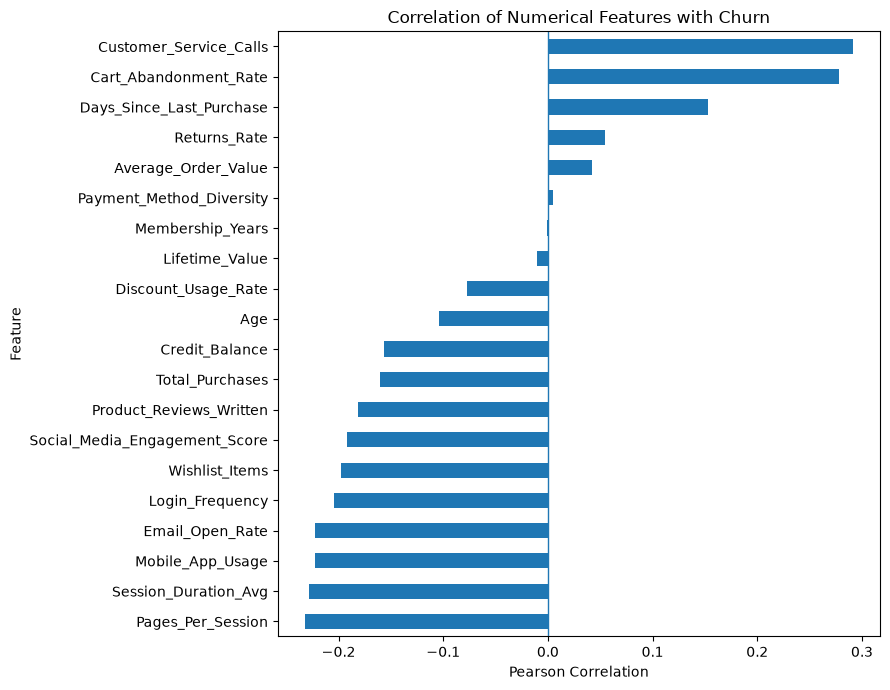

In [15]:
plt.figure(figsize=(9, 7))
correlation_with_churn.sort_values().plot(kind="barh")
plt.axvline(0, linewidth=1)
plt.title("Correlation of Numerical Features with Churn")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    "visualisation/Correlation_of_Numerical_Features_with_Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Key Behavioral Visualizations

Focus on variables that represent engagement, purchase activity, and friction in the customer journey.

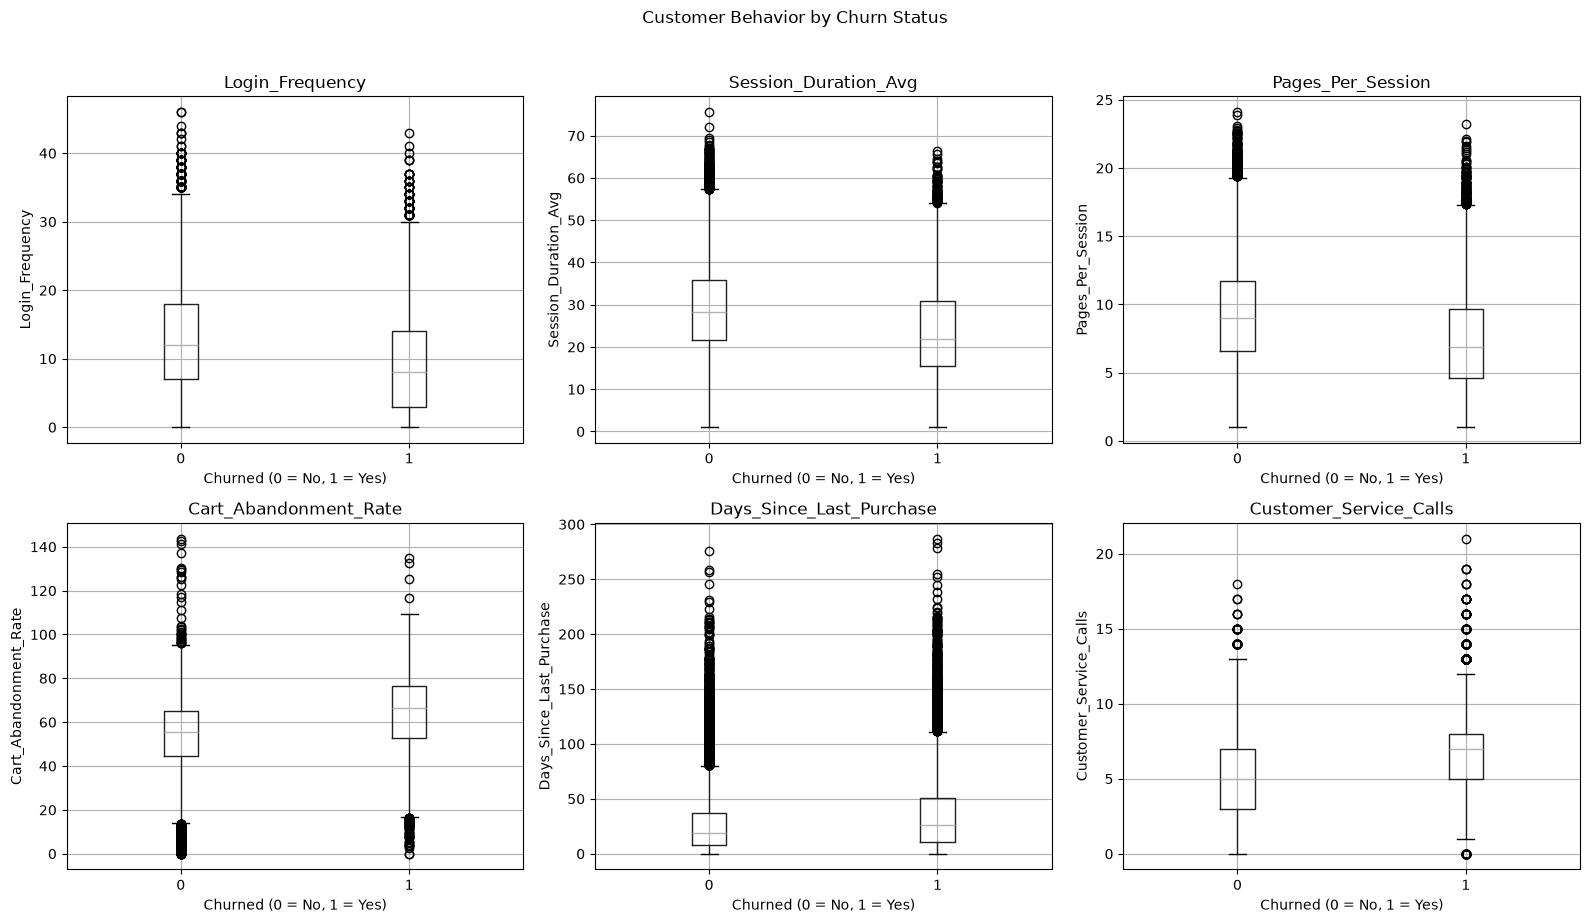

In [16]:
plot_features = [
    "Login_Frequency",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Cart_Abandonment_Rate",
    "Days_Since_Last_Purchase",
    "Customer_Service_Calls",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feature in zip(axes.flat, plot_features):
    analysis_df.boxplot(column=feature, by="Churned", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Churned (0 = No, 1 = Yes)")
    ax.set_ylabel(feature)

plt.suptitle("Customer Behavior by Churn Status", y=1.02)
plt.tight_layout()
plt.savefig(
    "visualisation/Customer_Behavior_by_Churn_Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Categorical Churn Analysis

Compare churn rates across gender, country, and signup quarter. Categories with very small sample sizes should be interpreted cautiously.

In [17]:
categorical_features = ["Gender", "Country", "Signup_Quarter"]

for feature in categorical_features:
    summary = (
        analysis_df.groupby(feature)["Churned"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n--- {feature} ---")
    display(summary.rename(columns={"mean": "Churn_Rate"}))


--- Gender ---


,count,Churn_Rate
Gender,,
Other,937,0.313
Female,25116,0.290
Male,23947,0.287



--- Country ---


,count,Churn_Rate
Country,,
Australia,4061,0.299
Canada,6023,0.294
USA,17384,0.291
India,3512,0.290
Germany,4925,0.288
UK,7534,0.288
Japan,2548,0.278
France,4013,0.273



--- Signup_Quarter ---


,count,Churn_Rate
Signup_Quarter,,
Q2,12521,0.297
Q1,12453,0.293
Q3,12558,0.284
Q4,12468,0.282


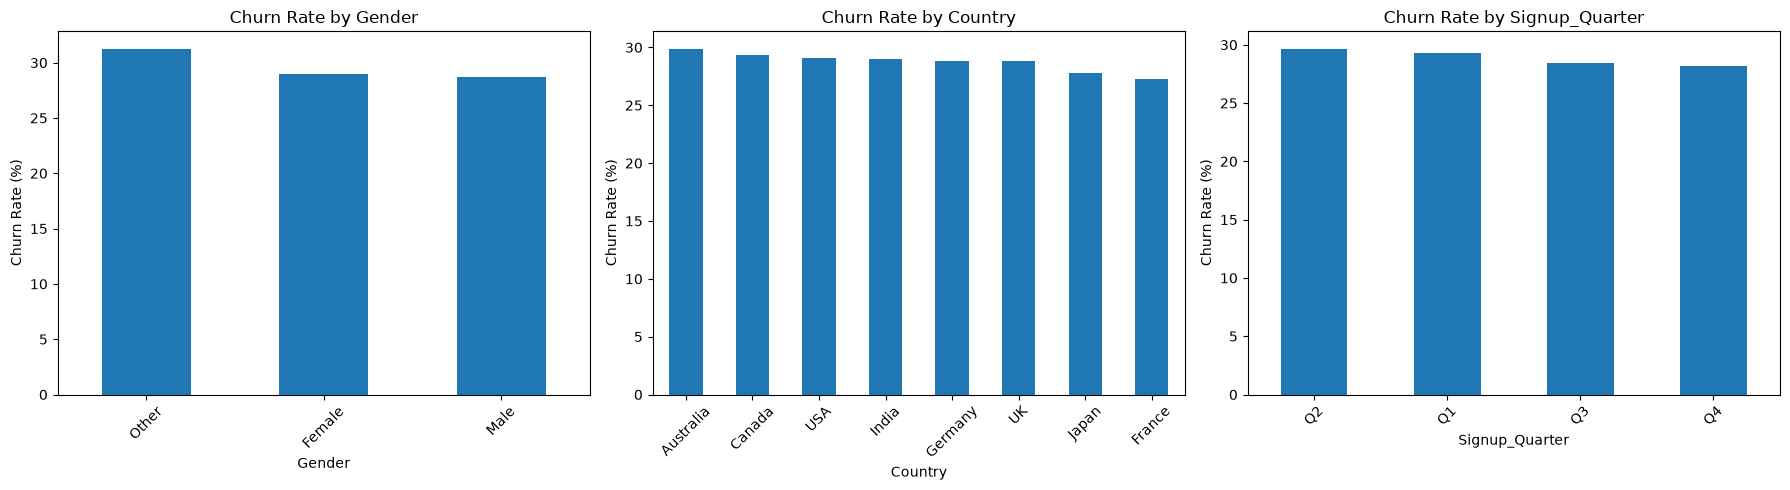

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, categorical_features):

    rates = (
        analysis_df.groupby(feature)["Churned"]
        .mean()
        .sort_values(ascending=False)
    )

    rates.mul(100).plot(kind="bar", ax=ax)

    ax.set_title(f"Churn Rate by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

# Save the complete figure
plt.savefig(
    "visualisation/churn_rate_by_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Feature-to-Feature Correlation

Strong feature-to-feature correlations can indicate overlapping information. This is especially relevant for linear models.

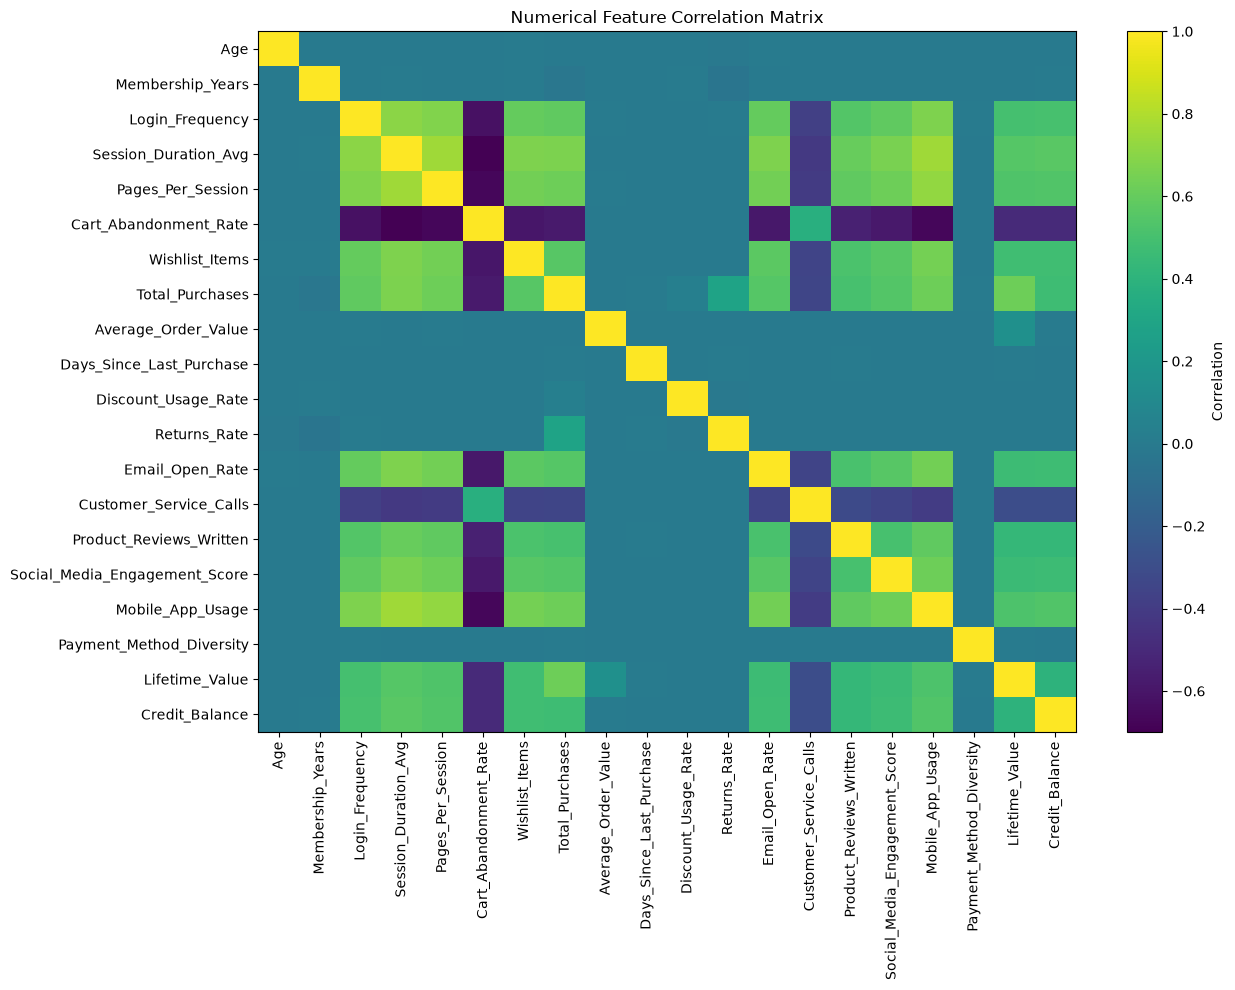

In [19]:
feature_corr = analysis_df[numeric_features].corr()

plt.figure(figsize=(13, 10))
plt.imshow(feature_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(feature_corr.columns)), feature_corr.columns, rotation=90)
plt.yticks(range(len(feature_corr.columns)), feature_corr.columns)
plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(
    "visualisation/Numerical_Feature_Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Prepare Data for Machine Learning

The model will use both numerical and categorical predictors. Importantly, imputation and scaling are placed inside a pipeline so they are learned only from the training data.

In [20]:
X = analysis_df.drop(columns="Churned")
y = analysis_df["Churned"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_model_features = X.select_dtypes(include=np.number).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_model_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print(f"Training churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")

Training set: (40000, 24)
Test set: (10000, 24)
Training churn rate: 28.9%
Test churn rate: 28.9%


## 13. Baseline Model — Logistic Regression

Logistic regression provides an interpretable baseline for churn classification.

In [21]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logistic_pipeline.fit(X_train, y_train)

logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_prob >= 0.50).astype(int)

In [22]:
def classification_summary(y_true, y_pred, y_prob, model_name):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred, zero_division=0)],
        "Recall": [recall_score(y_true, y_pred, zero_division=0)],
        "F1": [f1_score(y_true, y_pred, zero_division=0)],
        "ROC_AUC": [roc_auc_score(y_true, y_prob)]
    })

logistic_results = classification_summary(
    y_test, logistic_pred, logistic_prob, "Logistic Regression"
)

logistic_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.714,0.504,0.730,0.596,0.790


## 14. Random Forest Model

Random Forest can capture nonlinear relationships and interactions that a linear model may miss.

In [23]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.50).astype(int)

rf_results = classification_summary(
    y_test, rf_pred, rf_prob, "Random Forest"
)

pd.concat([logistic_results, rf_results], ignore_index=True)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.714,0.504,0.730,0.596,0.790
1,Random Forest,0.907,0.842,0.834,0.838,0.925


## 15. Model Comparison

Use F1 and ROC-AUC alongside accuracy because churn datasets can be imbalanced and the business cost of missed churners may be high.

In [24]:
model_comparison = pd.concat(
    [logistic_results, rf_results],
    ignore_index=True
).sort_values("ROC_AUC", ascending=False)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,0.907,0.842,0.834,0.838,0.925
0,Logistic Regression,0.714,0.504,0.730,0.596,0.790


## 16. Random Forest Confusion Matrix

The confusion matrix shows retained/churned predictions at the default 0.50 threshold.

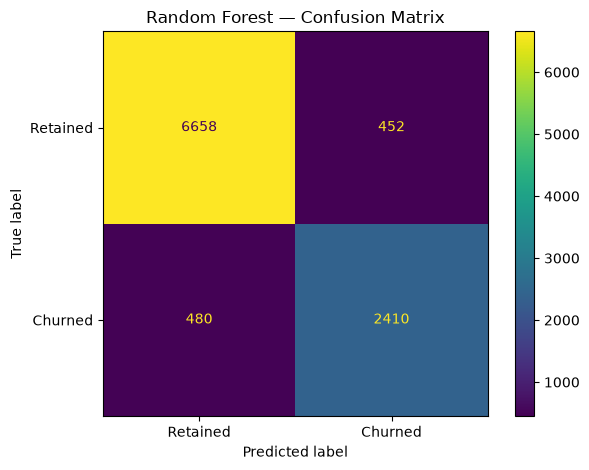

In [25]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Churned"]
)

disp.plot()
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "visualisation/Random_Forest—Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 17. ROC Curve

ROC-AUC measures how well the model ranks churned customers above retained customers across classification thresholds.

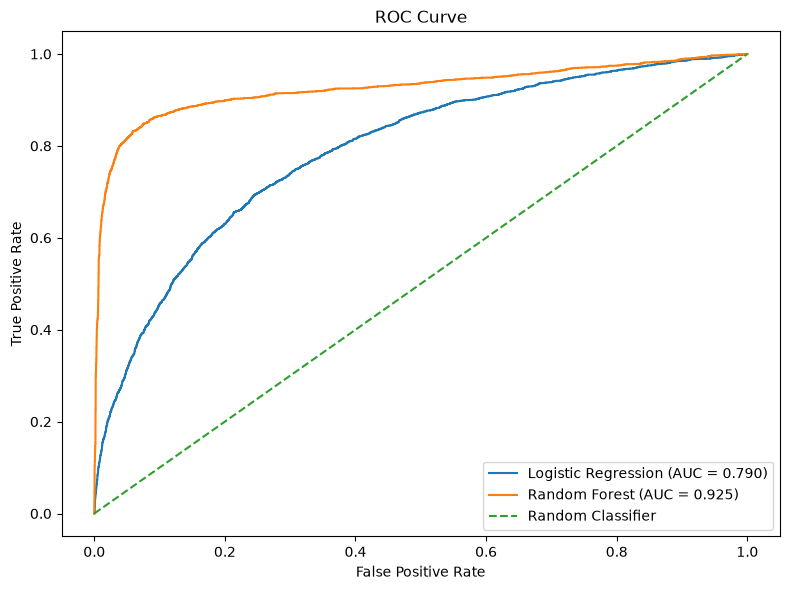

In [26]:
fpr_log, tpr_log, _ = roc_curve(y_test, logistic_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, logistic_prob):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualisation/ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 18. Precision–Recall Curve

The Precision–Recall curve is useful when identifying churners is more important than overall accuracy.

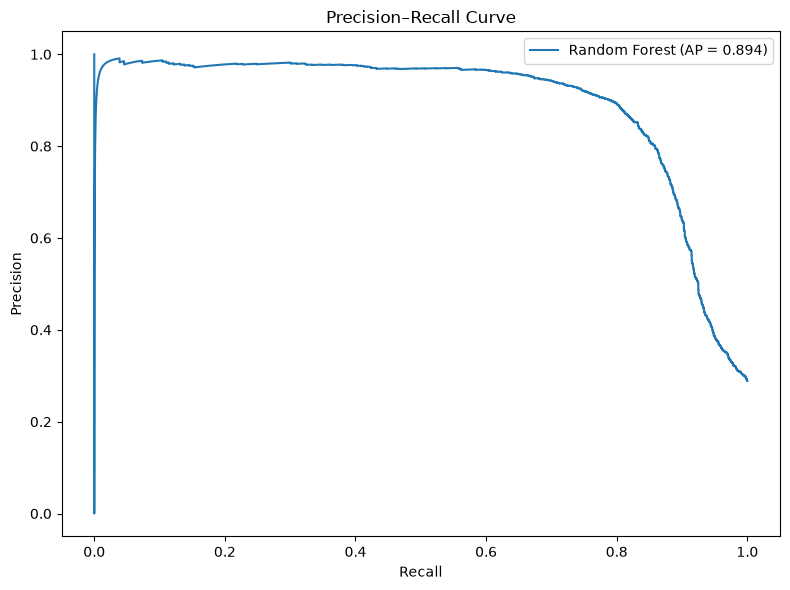

In [27]:
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_prob)
ap_rf = average_precision_score(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP = {ap_rf:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualisation/Precision–Recall_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 19. Feature Importance

Random Forest importance is shown for the transformed model features. These values indicate predictive usefulness inside this model; they do not prove causation.

In [28]:
rf_estimator = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_estimator.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(20))

,Feature,Importance
13,num__Customer_Service_Calls,0.123
18,num__Lifetime_Value,0.111
5,num__Cart_Abandonment_Rate,0.088
0,num__Age,0.070
10,num__Discount_Usage_Rate,0.052
9,num__Days_Since_Last_Purchase,0.049
8,num__Average_Order_Value,0.047
12,num__Email_Open_Rate,0.044
7,num__Total_Purchases,0.044
4,num__Pages_Per_Session,0.039


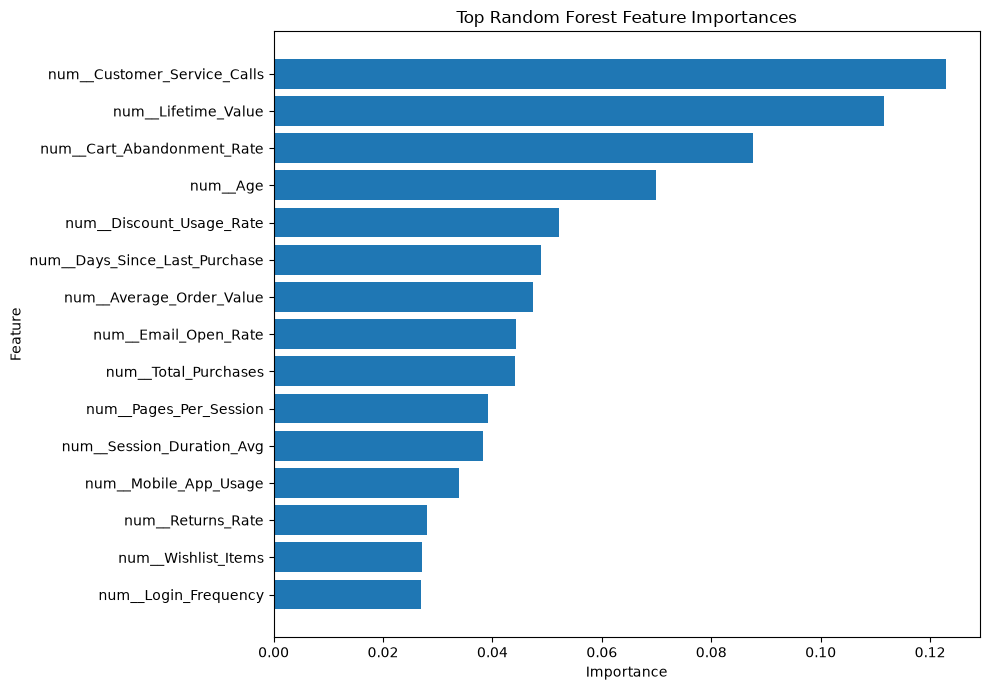

In [29]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(
    "visualisation/Top_Random_Forest_Feature_Importances.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 20. Cross-Validation

Cross-validation provides a more stable estimate of model performance than relying on a single train/test split.

In [30]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

cv_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean(),
        cv_scores["test_roc_auc"].mean()
    ],
    "Std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_precision"].std(),
        cv_scores["test_recall"].std(),
        cv_scores["test_f1"].std(),
        cv_scores["test_roc_auc"].std()
    ]
})

cv_results

,Metric,Mean,Std
0,Accuracy,0.908,0.004
1,Precision,0.845,0.007
2,Recall,0.833,0.010
3,F1,0.839,0.006
4,ROC-AUC,0.922,0.004


## 21. Threshold Optimization

A 0.50 probability threshold is not always the best business threshold. Here we select the threshold that maximizes F1 on the held-out test set as an analytical exercise.

**Important:** for production deployment, threshold selection should be performed on a validation set or through nested cross-validation rather than tuning directly on the final test set.

In [31]:
threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.01):
    pred = (rf_prob >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]

best_threshold = float(best_threshold_row["Threshold"])
best_threshold_row

Threshold   0.560
Precision   0.894
Recall      0.799
F1          0.844
Name: 36, dtype: float64

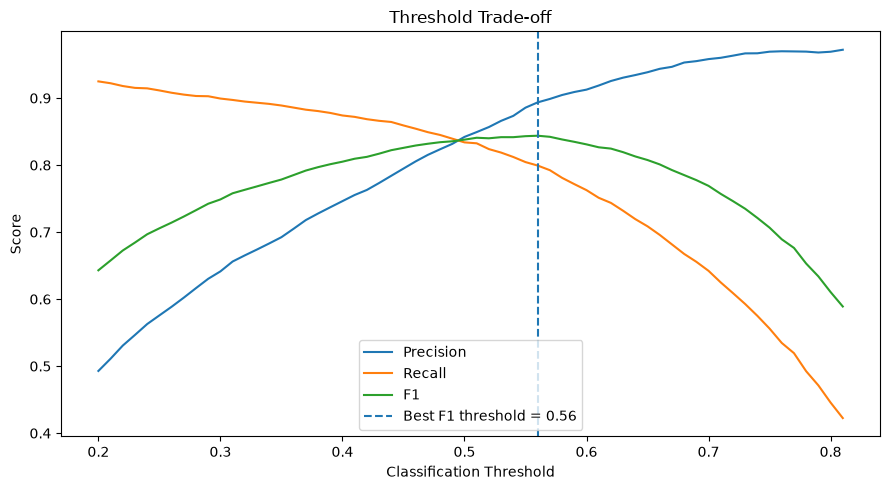

In [32]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")

plt.axvline(best_threshold, linestyle="--", label=f"Best F1 threshold = {best_threshold:.2f}")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Trade-off")
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualisation/Threshold_Trade_off.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 22. Churn Risk Segmentation

The model probability can be converted into simple risk groups for exploratory business analysis.

In [33]:
risk_df = X_test.copy()
risk_df["Actual_Churn"] = y_test.to_numpy()
risk_df["Churn_Probability"] = rf_prob

def risk_category(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    return "High Risk"

risk_df["Risk_Category"] = risk_df["Churn_Probability"].apply(risk_category)

risk_summary = (
    risk_df["Risk_Category"]
    .value_counts()
    .rename_axis("Risk_Category")
    .to_frame("Customers")
)

risk_summary["Percentage"] = (
    risk_summary["Customers"] / len(risk_df) * 100
).round(2)

risk_summary

,Customers,Percentage
Risk_Category,,
Low Risk,5948,59.480
High Risk,2415,24.150
Medium Risk,1637,16.370


## 23. High-Risk Customer Profile

Compare average numeric behavior across risk groups. This helps translate model output into customer-management questions.

In [34]:
risk_profile = (
    risk_df.groupby("Risk_Category")[numeric_model_features]
    .mean()
    .T
)

risk_profile

Risk_Category,High Risk,Low Risk,Medium Risk
Age,35.503,38.663,37.656
Membership_Years,2.918,3.016,3.058
Login_Frequency,8.378,14.155,6.858
Session_Duration_Avg,22.344,31.487,19.559
Pages_Per_Session,6.972,10.143,6.131
Cart_Abandonment_Rate,66.194,50.687,67.678
Wishlist_Items,3.070,5.321,2.399
Total_Purchases,10.753,15.114,9.026
Average_Order_Value,137.230,114.627,126.223
Days_Since_Last_Purchase,35.563,26.433,34.957


## 24. Business Insights Framework

Use the following structure when writing the final project findings:

- **Churn level:** quantify the overall churn rate.
- **Customer engagement:** identify engagement variables associated with lower or higher churn.
- **Purchase behavior:** examine purchase frequency, order value, and recency.
- **Customer friction:** investigate cart abandonment, returns, and service calls.
- **Modeling:** report ROC-AUC, F1, recall, and precision rather than accuracy alone.
- **Risk segmentation:** describe characteristics of high-risk customers.

Do not write that a variable *causes* churn unless a causal study supports that claim.

In [35]:
# Generate a compact set of project metrics for the final report.

final_metrics = pd.DataFrame({
    "Metric": [
        "Customers",
        "Features",
        "Overall Churn Rate",
        "Retained Customers",
        "Churned Customers",
        "Random Forest ROC-AUC",
        "Random Forest F1"
    ],
    "Value": [
        len(analysis_df),
        analysis_df.shape[1] - 1,
        f"{analysis_df['Churned'].mean():.1%}",
        int((analysis_df["Churned"] == 0).sum()),
        int((analysis_df["Churned"] == 1).sum()),
        f"{roc_auc_score(y_test, rf_prob):.3f}",
        f"{f1_score(y_test, rf_pred):.3f}"
    ]
})

final_metrics

,Metric,Value
0,Customers,50000
1,Features,24
2,Overall Churn Rate,28.9%
3,Retained Customers,35550
4,Churned Customers,14450
5,Random Forest ROC-AUC,0.925
6,Random Forest F1,0.838


# 25. EDA Conclusion

This analysis provides a structured view of e-commerce customer churn.

The dataset contains **50,000 customer records and 25 variables**, including customer demographics, engagement, purchase behavior, service interactions, financial indicators, and a binary churn target.

The exploratory analysis should be used to identify **associations** with churn. Variables such as customer engagement, purchase recency, cart abandonment, service interactions, and purchasing behavior can be examined as potential churn indicators.

The machine-learning stage compares an interpretable Logistic Regression baseline with a Random Forest model. Performance should be reported using ROC-AUC, F1, precision, and recall, with the business objective determining the most appropriate threshold.

### Final takeaway

The strongest portfolio story is not simply:

> “I built a churn model.”

It is:

> **“I investigated customer behavior, identified patterns associated with churn, evaluated predictive models, and translated the results into a framework for customer-retention decisions.”**

## 26. Business Recommendations

Potential recommendations should be tied to the strongest findings produced by the notebook:

1. **Prioritize high-risk customers** for retention campaigns.
2. **Investigate declining engagement** as an early warning signal.
3. **Reduce customer friction** around cart abandonment and service issues.
4. **Use purchase recency and frequency** to identify customers who may need re-engagement.
5. **Personalize retention offers** instead of giving discounts to every customer.
6. **Monitor model performance over time** because customer behavior can change.

These are decision frameworks, not guaranteed causal effects.

## 27. Project Reproducibility

Recommended project structure:

```text
E-Commerce-Customer-Churn-Analysis/
│
├── Data/
│   └── ecommerce_customer_churn_dataset.csv
│
├── Notebooks/
│   └── E-Commerce_Customer_Churn_Analysis_Professional.ipynb
│
├── README.md
├── requirements.txt
└── .gitignore
```

### Reproducibility checklist

- Keep the raw dataset unchanged.
- Keep data cleaning inside the notebook or a dedicated script.
- Do not use `pip install` inside the notebook.
- Use a fixed `random_state`.
- Keep preprocessing inside the modeling pipeline.
- Document assumptions such as the age validation rule.
- Separate exploratory findings from predictive-model results.

## Author

**Abdullah Al Raihan**

Data Science / Data Analysis Portfolio Project

> Learning by building real-world data projects.